In [17]:
import scanpy as sc
import anndata as ad
import h5py
import numpy as np
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt

In [2]:
f = h5py.File("/Volumes/SSD/hlca_50pc_50k.hdf5")
og = f["trajectory"]["0"]
ms = f["trajectory"]["20"]

In [3]:
adata = sc.read_h5ad("../data/hlca.h5ad", backed="r")
labels, colors = np.unique(adata.obs["cell_type"], return_inverse=True)
idx = np.where(colors != 49)

In [4]:
og = np.array(og)[idx]
ms = np.array(ms)[idx]

In [5]:
len(og)

1659134

In [6]:
og_adata = ad.AnnData(np.array(og))
ms_adata = ad.AnnData(np.array(ms))

In [7]:
sc.pp.neighbors(og_adata, n_neighbors=10, use_rep="X")
sc.pp.neighbors(ms_adata, n_neighbors=10, use_rep="X")

/Users/nveshaan/Developer/msde/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
sc.tl.leiden(og_adata, resolution=0.8, key_added="seurat_leiden")
sc.tl.leiden(ms_adata, resolution=0.8, key_added="seurat_leiden")

/var/folders/kw/c3pr6h9d7yd2y0dbhl8y5hgc0000gn/T/ipykernel_9080/2634146003.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(og_adata, resolution=0.8, key_added="seurat_leiden")
/var/folders/kw/c3pr6h9d7yd2y0dbhl8y5hgc0000gn/T/ipykernel_9080/2634146003.py:2: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False

In [15]:
og_ari = adjusted_rand_score(idx[0], og_adata.obs["seurat_leiden"])
ms_ari = adjusted_rand_score(idx[0], ms_adata.obs["seurat_leiden"])

In [16]:
print("ARI before MSDE: ", og_ari)
print("ARI after MSDE: ", ms_ari)

ARI before MSDE:  0.0
ARI after MSDE:  0.0


In [28]:
np.unique(np.array(og_adata.obs["seurat_leiden"]))

array(['0', '1', '10', '100', '101', '102', '103', '104', '105', '106',
       '107', '108', '109', '11', '110', '111', '12', '13', '14', '15',
       '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25',
       '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35',
       '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45',
       '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55',
       '56', '57', '58', '59', '6', '60', '61', '62', '63', '64', '65',
       '66', '67', '68', '69', '7', '70', '71', '72', '73', '74', '75',
       '76', '77', '78', '79', '8', '80', '81', '82', '83', '84', '85',
       '86', '87', '88', '89', '9', '90', '91', '92', '93', '94', '95',
       '96', '97', '98', '99'], dtype=object)

In [33]:
np.unique(np.array(ms_adata.obs["seurat_leiden"]))

array(['0', '1', '10', ..., '9997', '9998', '9999'],
      shape=(33083,), dtype=object)

In [30]:
np.unique(colors)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50])

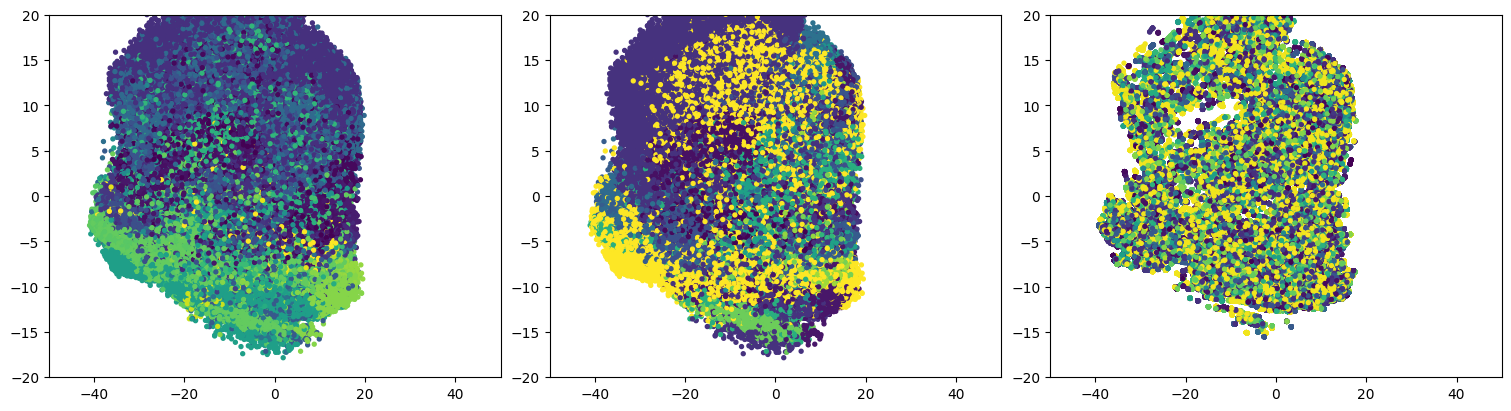

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), layout='constrained')

axes[0].scatter(og[:, 0], og[:, 1], c=colors[idx], s=8)
axes[0].set_xlim(-50, 50)
axes[0].set_ylim(-20, 20)
axes[1].scatter(og[:, 0], og[:, 1], c=colors[np.array(og_adata.obs["seurat_leiden"], dtype=int)], s=8)
axes[1].set_xlim(-50, 50)
axes[1].set_ylim(-20, 20)
axes[2].scatter(ms[:, 0], ms[:, 1], c=colors[np.array(ms_adata.obs["seurat_leiden"], dtype=int)], s=8)
axes[2].set_xlim(-50, 50)
axes[2].set_ylim(-20, 20)

plt.show()